In [ ]:
from nltk.corpus import brown
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForTokenClassification, Trainer, TrainingArguments, DataCollatorForTokenClassification, DistilBertTokenizerFast
from datasets import Dataset
from sklearn.metrics import accuracy_score
import os
import numpy as np
from huggingface_hub import model_info
from torch.utils.data import DataLoader
plt.rcParams['text.parse_math'] = False

# notebook_login()

In [51]:
# A test to see if POS tagged sentences can be accessed from NLTK.
print(brown.tagged_sents())

[[('The', 'AT'), ('Fulton', 'NP-TL'), ('County', 'NN-TL'), ('Grand', 'JJ-TL'), ('Jury', 'NN-TL'), ('said', 'VBD'), ('Friday', 'NR'), ('an', 'AT'), ('investigation', 'NN'), ('of', 'IN'), ("Atlanta's", 'NP$'), ('recent', 'JJ'), ('primary', 'NN'), ('election', 'NN'), ('produced', 'VBD'), ('``', '``'), ('no', 'AT'), ('evidence', 'NN'), ("''", "''"), ('that', 'CS'), ('any', 'DTI'), ('irregularities', 'NNS'), ('took', 'VBD'), ('place', 'NN'), ('.', '.')], [('The', 'AT'), ('jury', 'NN'), ('further', 'RBR'), ('said', 'VBD'), ('in', 'IN'), ('term-end', 'NN'), ('presentments', 'NNS'), ('that', 'CS'), ('the', 'AT'), ('City', 'NN-TL'), ('Executive', 'JJ-TL'), ('Committee', 'NN-TL'), (',', ','), ('which', 'WDT'), ('had', 'HVD'), ('over-all', 'JJ'), ('charge', 'NN'), ('of', 'IN'), ('the', 'AT'), ('election', 'NN'), (',', ','), ('``', '``'), ('deserves', 'VBZ'), ('the', 'AT'), ('praise', 'NN'), ('and', 'CC'), ('thanks', 'NNS'), ('of', 'IN'), ('the', 'AT'), ('City', 'NN-TL'), ('of', 'IN-TL'), ('Atlant

In [52]:
# A test to see if POS tagged words can be accessed from NLTK.
brown_df = pd.DataFrame(data = list(brown.tagged_words()), columns = ['word', 'tag'])
brown_df.head(10)

,word,tag
0,The,AT
1,Fulton,NP-TL
2,County,NN-TL
3,Grand,JJ-TL
4,Jury,NN-TL
5,said,VBD
6,Friday,NR
7,an,AT
8,investigation,NN
9,of,IN


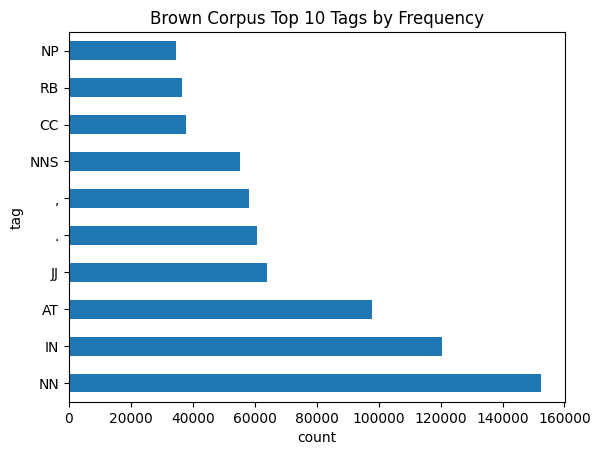

In [53]:
# A test to see the most frequent tags in the corpus.
brown_df["tag"].value_counts().head(10).plot.barh()
plt.title("Brown Corpus Top 10 Tags by Frequency")
plt.xlabel("count")
plt.show()

We will now start fine-tuning DistilBERT.

In [54]:
#We need to reduce / simplify the number of tags in the dataset, otherwise POS classification tasks will be very difficult.
def simplify_tag(tag):
    return tag.split("+")[0].split("-")[0]

tagged_sentences = list(brown.tagged_sents())

#Set means each element is unique, and this means it removes duplicate tags over the collected aggregation of all tags in each sentence in the brown corpus
brown_tags = set(simplify_tag(tag) for sent in tagged_sentences for word, tag in sent)

# We need a numerical class label for each tag in brown_tags to fine-tune DistilBERT.
# We need the tag name for each numerical class label in id_to_tag to interpret classification results.
tag_to_id = {tag: i for i, tag in enumerate(sorted(brown_tags))}
id_to_tag = {i: tag for tag, i in tag_to_id.items()}

print(f"Number of POS tags after simplification: {len(tag_to_id)}")

Number of POS tags after simplification: 105


In [ ]:
# This cell will setup the Brown Corpus in the format of the Dataset (which is used to fine-tune DistilBERT).

data = [
    {
        "tokens": [w for w, _ in sent],
        "tags": [simplify_tag(t) for _, t in sent],
    }
    for sent in tagged_sentences
]

# Each tagged sentence from the Brown Corpus becomes a dictionary, with the tokens list being the words in the sentence, the tags list being the respective tags in the sentence.
dataset = Dataset.from_list(data).train_test_split(test_size=0.2, seed=67)

In [ ]:
# This cell will handle tokenization and label alignment.

tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")

# Test tokenization with DistilBERT tokenizer.
print(tokenizer("Computational Linguistics"))

def tokenize_and_align(batch):
    encoding = tokenizer(
        batch["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding=False,
    )
    labels = []
    for i, tags in enumerate(batch["tags"]):
        # Return which original word each token came from because tokenizing breaks words up.
        word_ids = encoding.word_ids(batch_index=i)
        prev_word = None
        label_ids = []
        for wid in word_ids:
            if wid is None:
                # Pytorch loss function ignore.
                label_ids.append(-100)
            elif wid != prev_word:
                # The first subtoken of a word only contributes to the label.
                label_ids.append(tag_to_id[tags[wid]])
            else:
                # Pytorch loss function ignore.
                label_ids.append(-100)
            prev_word = wid
        labels.append(label_ids)
    encoding["labels"] = labels
    return encoding

#So now the dataset will have everything that is needed for the training process, we can also remove columns that aren't needed for training.
tokenized = dataset.map(
    tokenize_and_align,
    batched=True,
    remove_columns=["tokens", "tags"]
)


{'input_ids': [101, 15078, 15397, 102], 'attention_mask': [1, 1, 1, 1]}


Map: 100%|██████████| 11468/11468 [00:00<00:00, 20814.47 examples/s]


In [57]:
# This cell sets up the DistilBERT model to be fine-tuned.

model = AutoModelForTokenClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels = len(tag_to_id),
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10834.08it/s]


In [58]:
# #Metrics during training, f1 score and accuracy score

# def compute_metrics(pred):
#     logits, labels = pred
#     preds = np.argmax(logits, axis=-1)

#     #Ignore the -100 label that is needed for pytorch.
#     corrected_labels = [l for row in labels for l in row if l != -100]
#     corrected_preds  = [p for p_row, l_row in zip(preds, labels)
#                      for p, l in zip(p_row, l_row) if l != -100]

#     return {
#         "accuracy": accuracy_score(corrected_labels, corrected_preds),
#         "f1":       f1_score(corrected_labels, corrected_preds, average="weighted"),
#     }

In [ ]:
# This cell sets up training arguments and training of the base DistilBERT model for POS classification.

# I'm doing work on a Mac, need to support the device.
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1" 

training_args = TrainingArguments(
    output_dir = "distilbert-brown-pos",
    num_train_epochs = 3,
    learning_rate = 2e-5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size = 64,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    log_level="error"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["test"],
    data_collator=DataCollatorForTokenClassification(tokenizer),
    processing_class=tokenizer,
)

trainer.train()

/Users/tylerdinh/.pyenv/versions/3.12.6/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': '0.7595', 'grad_norm': '1.025', 'learning_rate': '1.768e-05', 'epoch': '0.3487'}
{'loss': '0.1163', 'grad_norm': '0.9019', 'learning_rate': '1.536e-05', 'epoch': '0.6974'}
{'eval_loss': '0.07194', 'eval_runtime': '29.66', 'eval_samples_per_second': '386.6', 'eval_steps_per_second': '6.068', 'epoch': '1'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s]
/Users/tylerdinh/.pyenv/versions/3.12.6/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': '0.08431', 'grad_norm': '1.042', 'learning_rate': '1.303e-05', 'epoch': '1.046'}
{'loss': '0.06581', 'grad_norm': '0.6659', 'learning_rate': '1.071e-05', 'epoch': '1.395'}
{'loss': '0.06215', 'grad_norm': '0.7147', 'learning_rate': '8.382e-06', 'epoch': '1.743'}
{'eval_loss': '0.05925', 'eval_runtime': '26.14', 'eval_samples_per_second': '438.6', 'eval_steps_per_second': '6.885', 'epoch': '2'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.20it/s]
/Users/tylerdinh/.pyenv/versions/3.12.6/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': '0.05563', 'grad_norm': '0.7934', 'learning_rate': '6.058e-06', 'epoch': '2.092'}
{'loss': '0.0483', 'grad_norm': '0.704', 'learning_rate': '3.733e-06', 'epoch': '2.441'}
{'loss': '0.04904', 'grad_norm': '0.8027', 'learning_rate': '1.409e-06', 'epoch': '2.789'}
{'eval_loss': '0.05675', 'eval_runtime': '26.09', 'eval_samples_per_second': '439.5', 'eval_steps_per_second': '6.899', 'epoch': '3'}


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.14it/s]


{'train_runtime': '1103', 'train_samples_per_second': '124.8', 'train_steps_per_second': '3.902', 'train_loss': '0.1475', 'epoch': '3'}


TrainOutput(global_step=4302, training_loss=0.14747297747198343, metrics={'train_runtime': 1102.5047, 'train_samples_per_second': 124.821, 'train_steps_per_second': 3.902, 'train_loss': 0.14747297747198343, 'epoch': 3.0})

## Evaluation

In [4]:
model_name = "nevertipyourlandlord/distilbert-brown-pos"

# If this runs, I fine-tuned DistilBERT (can check on web too)
print(model_info(model_name))

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

model.eval()

ModelInfo(id='nevertipyourlandlord/distilbert-brown-pos', author='nevertipyourlandlord', base_models=None, card_data=None, children_model_count=None, config={'architectures': ['DistilBertForTokenClassification'], 'model_type': 'distilbert', 'tokenizer_config': {'cls_token': '[CLS]', 'mask_token': '[MASK]', 'pad_token': '[PAD]', 'sep_token': '[SEP]', 'unk_token': '[UNK]'}}, created_at=datetime.datetime(2026, 4, 26, 22, 42, 1, tzinfo=datetime.timezone.utc), disabled=False, downloads=0, downloads_all_time=None, eval_results=None, gated=False, gguf=None, inference=None, inference_provider_mapping=None, last_modified=datetime.datetime(2026, 4, 26, 22, 43, 41, tzinfo=datetime.timezone.utc), library_name=None, likes=1, mask_token='[MASK]', model_index=None, pipeline_tag=None, private=False, resource_group=None, safetensors=SafeTensorsInfo(parameters={'F32': 66443625}, total=66443625), security_repo_status=None, sha='ab4cfa546cee300341baec6aafeda7a50544b610', siblings=[RepoSibling(rfilename='.

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

DistilBertForTokenClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
   